In [2]:
#%pip install matplotlib, seaborn, scikit-learn

In [4]:
import torch
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_from_disk


import torch
import os
import json
from typing import Dict, List, Union, Optional

In [6]:
PROJ_DIR = '/home/user/WORK/2608_MATS/EN'
DATA_DIR = os.path.join(PROJ_DIR, 'data')
RES_DIR = os.path.join(PROJ_DIR, 'results')
model_path = "/home/user/.cache/huggingface/hub/models--tencent--HY-MT1.5-1.8B/snapshots/dbad03788f49709801014c95d481a514c272ca52"
SYSTEM_PROMPT = "把英语翻译成俄：{text}"
SWITCH_LANG_TRHD = .8

MAX_TOKENS = 512
MAX_NEW_TOKENS = 200

In [7]:

tokenizer = AutoTokenizer.from_pretrained(model_path
                                          #, padding_side='left'
                                         )
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto"
)

layers = range(model.config.num_hidden_layers)  # 24 слоя (0-23)

model.config.num_hidden_layers

[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'beta_fast', 'alpha', 'mscale_all_dim', 'mscale', 'beta_slow'}
[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'beta_fast', 'alpha', 'mscale_all_dim', 'mscale', 'beta_slow'}
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

32

In [8]:
val_data_path = os.path.join(DATA_DIR, './wmt14_ru_en_validation_full')
steer_data_path = os.path.join(DATA_DIR, './wmt14_ru_en_500_samples')
val_dataset = load_from_disk(val_data_path)
steer_dataset = load_from_disk(steer_data_path)
activation_dir=os.path.join(RES_DIR, './activations_data_500')

In [ ]:
def get_activations_single(text, tokenizer, model, layers):
    """
    Extracts activations for a single text at the specified layers.
    Uses output_hidden_states instead of hooks.

    Returns:
        dict: {layer_idx: tensor(1, hidden_dim)}
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)

    # Forward pass with all hidden states saved
    with torch.no_grad():
        #outputs = model(inputs.input_ids, output_hidden_states=True)
        outputs = model(**inputs, output_hidden_states=True)

    # outputs.hidden_states is a tuple of (embeddings, layer_1, ..., layer_N)
    # Indexing: 0 — embeddings, 1 — layer 0, 2 — layer 1, ...
    layer_activations = {}
    for layer_idx in layers:
        # +1 because the first element is embeddings
        hidden_state = outputs.hidden_states[layer_idx + 1]

        # Take the last token (if dim == 3) or use as is (if dim == 2)
        if hidden_state.dim() == 3:
            layer_activations[layer_idx] = hidden_state[:, -1, :].detach().cpu()
        else:
            layer_activations[layer_idx] = hidden_state.detach().cpu()

    return layer_activations

def collect_activations_no_batch(dataset, tokenizer, model, layers, max_examples=500):
    """
    Collects activations for English and Russian texts one example at a time.

    Returns:
        dict: {
            'en': {layer_idx: tensor(N, hidden_dim)},
            'ru': {layer_idx: tensor(N, hidden_dim)}
        }
    """
    # Limit the number of examples
    if max_examples and max_examples < len(dataset):
        dataset = dataset.select(range(max_examples))

    print(f"📊 Processing {len(dataset)} examples one by one...")

    # Dictionaries for storing activations
    en_activations = {layer: [] for layer in layers}
    ru_activations = {layer: [] for layer in layers}

    # Iterate over the dataset one example at a time
    for idx in tqdm(range(len(dataset)), desc="Collecting activations"):
        example = dataset[idx]
        en_text = example['translation']['en']
        ru_text = example['translation']['ru']

        # Collect activations for the English text
        en_activ = get_activations_single(en_text, tokenizer, model, layers)

        # Collect activations for the Russian text
        ru_activ = get_activations_single(ru_text, tokenizer, model, layers)

        # Store activations
        for layer in layers:
            en_activations[layer].append(en_activ[layer])
            ru_activations[layer].append(ru_activ[layer])


    # Concatenate all examples into a single tensor for each layer
    for layer in layers:
        en_activations[layer] = torch.cat(en_activations[layer], dim=0)
        ru_activations[layer] = torch.cat(ru_activations[layer], dim=0)

    print(f"✅ Collected activations for {len(dataset)} examples")
    print(f"   EN shape: {en_activations[layers[0]].shape}")
    print(f"   RU shape: {ru_activations[layers[0]].shape}")

    return {'en': en_activations, 'ru': ru_activations}

import torch
import os

def save_activations(activations, output_dir="./activations"):
    """
    Saves the collected activations to separate files.

    Args:
        activations: dict from collect_activations_no_batch
        output_dir: directory for saving
    """
    os.makedirs(output_dir, exist_ok=True)

    # Save English activations
    en_path = os.path.join(output_dir, "en_activations.pt")
    torch.save(activations['en'], en_path)
    print(f"✅ Saved English activations to {en_path}")

    # Save Russian activations
    ru_path = os.path.join(output_dir, "ru_activations.pt")
    torch.save(activations['ru'], ru_path)
    print(f"✅ Saved Russian activations to {ru_path}")

    # Also save layer info for reference
    info = {
        'layers': list(activations['en'].keys()),
        'num_examples': activations['en'][list(activations['en'].keys())[0]].shape[0],
        'hidden_dim': activations['en'][list(activations['en'].keys())[0]].shape[1]
    }

    info_path = os.path.join(output_dir, "activations_info.json")
    import json
    with open(info_path, 'w') as f:
        json.dump(info, f, indent=2)
    print(f"✅ Saved info to {info_path}")

# === USAGE ===

# After collecting activations
activations = collect_activations_no_batch(
    dataset=steer_dataset,
    tokenizer=tokenizer,
    model=model,
    layers=layers,
    max_examples=10
)

# Save activations
#save_activations(activations, output_dir=activation_dir)

In [9]:
def load_activations(
    input_dir: str = "./activations_data_500"
) -> Dict[str, Dict[int, torch.Tensor]]:
    """
    Загружает сохраненные активации из папки.
    
    Returns:
        dict: {'en': {layer: tensor}, 'ru': {layer: tensor}}
    """
    en_path = os.path.join(input_dir, "en_activations.pt")
    ru_path = os.path.join(input_dir, "ru_activations.pt")
    info_path = os.path.join(input_dir, "activations_info.json")
    
    # Загружаем активации
    en_activations = torch.load(en_path, map_location='cpu')
    ru_activations = torch.load(ru_path, map_location='cpu')
    
    print(f"✅ En activations loaded from {en_path}")
    print(f"✅ Ru activations loaded from {ru_path}")
    
    # Загружаем информацию
    if os.path.exists(info_path):
        with open(info_path, 'r') as f:
            info = json.load(f)
        print(f"📊 info: {info}")
    
    return {'en': en_activations, 'ru': ru_activations}

# Сохраняем активации
activations = load_activations(activation_dir)

✅ En activations loaded from /home/user/WORK/2608_MATS/EN/results/./activations_data_500/en_activations.pt
✅ Ru activations loaded from /home/user/WORK/2608_MATS/EN/results/./activations_data_500/ru_activations.pt
📊 info: {'layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], 'num_examples': 500, 'hidden_dim': 2048}


In [10]:
def compute_steering_vectors(activations, layers):
    steering_vectors = {}
    for layer in layers:
        en_mean = activations['en'][layer].mean(dim=0, keepdim=True)
        ru_mean = activations['ru'][layer].mean(dim=0, keepdim=True)
        steering_vectors[layer] = ru_mean - en_mean
    return steering_vectors

steering_vectors = compute_steering_vectors(activations, layers)
steering_vectors[0].shape

torch.Size([1, 2048])

In [11]:
# this code from metrics.ipynb

import json
import re
from sacrebleu import corpus_bleu, CHRF
from tqdm import tqdm
from typing import List, Dict, Tuple

def is_russian(text: str, threshold: float = SWITCH_LANG_TRHD) -> bool:
    """
    Checks whether the text is Russian based on the proportion of Cyrillic characters.
    """
    if not text or len(text.strip()) == 0:
        return True
    
    # Remove spaces, digits, punctuation, and emoji
    clean_text = re.sub(r'[\s\d\W]', '', text)
    if len(clean_text) == 0:
        return True
    
    cyrillic = len(re.findall(r'[а-яА-ЯёЁ]', clean_text))
    ratio = cyrillic / len(clean_text)
    return ratio >= threshold

def detect_language_switch(text: str) -> bool:
    """
    Returns True if the text is NOT Russian (a switch to another language).
    """
    return not is_russian(text)

In [17]:
# but this function was modified for ram data
def compute_metrics_for_translations(filepath: str = None, records: List[Dict] = None) -> Dict:
    """
    Loads a JSONL file with translations or accepts a list of records and computes metrics.

    Args:
        filepath: path to the JSONL file (if None, records is used)
        records: list of records with fields 'source', 'reference', 'translation'

    Returns:
        Dictionary with metrics: average values across all examples
    """
    # If filepath is provided — load the data
    if records is not None:
        print(f"📂 Received {len(records)} records directly")
    elif filepath is not None:
        records = []
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                records.append(json.loads(line))
        print(f"📂 Loaded {len(records)} records from {filepath}")
    else:
        raise ValueError("Either filepath or records must be provided")

    # Extract texts
    sources = [r['source'] for r in records]
    references = [r['reference'] for r in records]
    predictions = [r['translation'] for r in records]

    # 1. Compute BLEU
    bleu_score = corpus_bleu(predictions, [references])
    print(f"📊 BLEU: {bleu_score.score:.2f}")

    # 2. Compute chrF
    chrf_scorer = CHRF(word_order=2)
    chrf_score = chrf_scorer.corpus_score(predictions, [references])
    print(f"📊 chrF: {chrf_score.score:.2f}")

    # 3. Count language switches
    switch_count = 0
    switch_examples = []

    for i, pred in enumerate(predictions):
        if detect_language_switch(pred):
            #print('L switch detected: ', pred)
            switch_count += 1
            if len(switch_examples) < 10:
                switch_examples.append({
                    'id': i,
                    'source': sources[i][:100] + "...",
                    'prediction': pred[:100] + "..."
                })

    switch_rate = switch_count / len(predictions) * 100
    print(f"📊 Language switches: {switch_count} / {len(predictions)} ({switch_rate:.2f}%)")

    # 4. Length statistics
    src_lengths = [len(s.split()) for s in sources]
    ref_lengths = [len(r.split()) for r in references]
    pred_lengths = [len(p.split()) for p in predictions]

    print(f"\n📏 Length statistics (in words):")
    print(f"  Source: avg {sum(src_lengths)/len(src_lengths):.1f}, "
          f"max {max(src_lengths)}, min {min(src_lengths)}")
    print(f"  Reference: avg {sum(ref_lengths)/len(ref_lengths):.1f}, "
          f"max {max(ref_lengths)}, min {min(ref_lengths)}")
    print(f"  Translation: avg {sum(pred_lengths)/len(pred_lengths):.1f}, "
          f"max {max(pred_lengths)}, min {min(pred_lengths)}")

    # 5. Switch examples (for manual analysis)
    if switch_examples:
        print(f"\n⚠️ Switch examples (first {len(switch_examples)}):")
        for ex in switch_examples:
            print(f"  [{ex['id']}] Source: {ex['source']}")
            print(f"      Translation: {ex['prediction']}")
            print()

    # Return all metrics
    return {
        'total_examples': len(records),
        'bleu': bleu_score.score,
        'chrf': chrf_score.score,
        'switch_count': switch_count,
        'switch_rate': switch_rate,
        'avg_src_len': sum(src_lengths) / len(src_lengths),
        'avg_ref_len': sum(ref_lengths) / len(ref_lengths),
        'avg_pred_len': sum(pred_lengths) / len(pred_lengths),
        'switch_examples': switch_examples
    }

In [18]:
def translate_with_steering_multi(
    text: str,
    tokenizer,
    model,
    steering_vectors: Dict[int, torch.Tensor],
    steering_config: Union[Dict[int, float], torch.Tensor],
    system_prompt: str = SYSTEM_PROMPT,
    max_new_tokens: int = MAX_NEW_TOKENS
) -> str:
    """
    Translates text using steering vectors applied to layer outputs (resid_post).
    """
    prompt = system_prompt.format(text=text)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_TOKENS).to(model.device)
    
    # Convert single tensor to dict for unified handling
    if isinstance(steering_config, torch.Tensor):
        steering_config = {23: steering_config}
    
    hooks = []
    
    def make_post_hook(layer_idx: int, alpha: float):
        def post_hook(module, input, output):
            #print(f"post_hook here layer_idx{layer_idx} alpha{alpha}")

            x = output[0]  # [B, S, D] or [B, D]
            v = steering_vectors[layer_idx].to(x.device, x.dtype).reshape(1, 1, -1)  # [1, 1, D]
            x_mod = x + v * alpha
            return x_mod  # Return ONLY the modified tensor
        return post_hook
    
    # Register hooks for all layers in config
    for layer_idx, alpha in steering_config.items():
        hook = model.model.layers[layer_idx].register_forward_hook(
            make_post_hook(layer_idx, alpha)
        )
        hooks.append(hook)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
    finally:
        for hook in hooks:
            hook.remove()
    
    generated = outputs[0][inputs.input_ids.shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=False)

def test_steering_on_validation_multi(
    dataset,
    tokenizer,
    model,
    steering_vectors: Dict[int, torch.Tensor],
    configs: List[Dict[int, float]],
    num_examples: int = 50,
    system_prompt: str = SYSTEM_PROMPT,
    max_new_tokens: int = MAX_NEW_TOKENS,
    output_file: Optional[str] = None
) -> Dict:
    """
    Tests steering vectors (resid_post) on validation dataset.
    
    Args:
        dataset: Dataset with 'translation.en' and 'translation.ru' fields
        tokenizer: Tokenizer instance
        model: Model instance
        steering_vectors: Dict mapping layer index to steering tensor
        configs: List of config dicts {layer: alpha}
                 Examples: [
                     {23: 0.5},                    # layer 24 only
                     {24: 0.5, 28: 0.3},           # layers 25 and 29
                     {23: 0.3, 24: 0.3, 28: 0.3}   # three layers
                 ]
        num_examples: Number of examples to use
        system_prompt: Prompt template for translation
        max_new_tokens: Maximum length of generated text
        output_file: Optional template for saving results
    
    Returns:
        dict: {config_index: {'config': config, 'metrics': metrics, 'filepath': path}}
    """
    # Limit dataset size
    if num_examples and num_examples < len(dataset):
        dataset = dataset.select(range(num_examples))
    
    results = {}
    os.makedirs("./outputs", exist_ok=True)
    
    for config_idx, config in enumerate(configs):
        # Create readable config description
        config_desc = "+".join([
            f"L{l+1}a{a:.2f}" for l, a in sorted(config.items())
        ])
        print(f"\n📊 Testing config {config_idx+1}: {config_desc}")
        print("-" * 60)
        
        # Generate translations
        records = []
        for idx in tqdm(range(len(dataset)), desc=f"Config {config_idx+1}"):
            src = dataset[idx]['translation']['en']
            ref = dataset[idx]['translation']['ru']
            
            # Generate with multi-layer hooks (resid_post)
            pred = translate_with_steering_multi(
                text=src,
                tokenizer=tokenizer,
                model=model,
                steering_vectors=steering_vectors,  # <-- Передаём словарь с векторами
                steering_config=config,
                system_prompt=system_prompt,
                max_new_tokens=max_new_tokens
            )
            
            records.append({
                'id': idx,
                'source': src,
                'reference': ref,
                'translation': pred,
                'config': config_desc
            })
        
        # Save to JSONL
        if output_file:
            filepath = output_file.format(config_idx=config_idx)
        else:
            filepath = f"{RES_DIR}/steering_residpost_config_{config_idx+1}.jsonl"
        
        with open(filepath, 'w', encoding='utf-8') as f:
            for r in records:
                f.write(json.dumps(r, ensure_ascii=False) + '\n')
        
        # Compute metrics
        metrics = compute_metrics_for_translations(records=records)
        results[config_idx] = {
            'config': config,
            'config_desc': config_desc,
            'metrics': metrics,
            'filepath': filepath
        }
        
        print(f"  BLEU={metrics['bleu']:.2f}, switch_rate={metrics['switch_rate']:.1f}%")
    
    return results

In [14]:
#steering_vector_tmp = steering_vectors[0] #if alpha=0 no matter what is in steering_vector_tmp 

# Промпт
text = "The quick brown fox jumps over the lazy dog."
system_prompt = SYSTEM_PROMPT
prompt = system_prompt.format(text=text)

print(f"Промпт: {prompt}\n")
# 1. Генерация БЕЗ хука
inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
generated = outputs[0][inputs.input_ids.shape[1]:]
result_no_hook = tokenizer.decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(f"No hook: {result_no_hook}")

tmp_cfg = {23: 0.0}

result_with_hook = translate_with_steering_multi(
                    text, tokenizer, model, steering_vectors, tmp_cfg
                )
print(f"with hook: {result_with_hook}")

Промпт: 把英语翻译成俄：The quick brown fox jumps over the lazy dog.

No hook: 
Быстрый коричневый лис выскакивает через ленивого собаку.
with hook: 
Быстрый коричневый лис выскакивает через ленивого собаку.


In [15]:
import torch

# 1. Проверка, что CUDA доступна
print(f"CUDA enabled: {torch.cuda.is_available()}")

# 2. Количество GPU
print(f"Number of GPUs: {torch.cuda.device_count()}")

# 3. Имя GPU
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

# Проверяем, где лежат параметры модели
first_param = next(model.parameters())
print(f"Models device: {first_param.device}")

# 5. Проверка во время генерации (перед forward pass)
inputs = tokenizer("Hello", return_tensors="pt").to(model.device)
print(f"input device: {inputs.input_ids.device}")

CUDA enabled: True
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 3070 Laptop GPU
Models device: cuda:0
input device: cuda:0


In [19]:
layers_to_test = range(22,31)
alphas = [0.4, 0.45, 0.5, 0.55, 0.6]
configs = [{layer: alpha} for layer in layers_to_test for alpha in alphas]
results = test_steering_on_validation_multi(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    configs=configs,
    num_examples=75,
    system_prompt=SYSTEM_PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)


📊 Testing config 1: L23a0.40
------------------------------------------------------------


Config 1: 100%|████████████████████████████████| 75/75 [04:01<00:00,  3.21s/it]


📂 Received 75 records directly
📊 BLEU: 14.27
📊 chrF: 47.12
📊 Language switches: 9 / 75 (12.00%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 30.9, max 108, min 5

⚠️ Switch examples (first 9):
  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [23] Source: And that's not all....
      Translation:  There are many other things that can be done to make the process of learning a language more effect...

  [33] Source: These restrictions are not without consequence....
      Translation:  They have led to a significant increase in the number of people seeking asylum in the region, and h...

  [49] Source: It is too early to say with certainty that these legislative changes in the electoral system will ha...
      Translation:  However, it is w

Config 2: 100%|████████████████████████████████| 75/75 [04:40<00:00,  3.73s/it]


📂 Received 75 records directly
📊 BLEU: 15.06
📊 chrF: 48.15
📊 Language switches: 9 / 75 (12.00%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 30.3, max 103, min 5

⚠️ Switch examples (first 9):
  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      Translation:  There are many other things that can be done to make the process of learning a language more effect...

  [33] Source: These restrictions are not without consequence....
      Translation:  They have led to a s

...

📂 Received 75 records directly
📊 BLEU: 15.81
📊 chrF: 48.57
📊 Language switches: 10 / 75 (13.33%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 29.0, max 104, min 0

⚠️ Switch examples (first 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.
Республиканская стратегия противодействия переизбранию Оба...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the state of Texas passed a law that made it mandatory for all voters to present ...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  The Russi

Config 44: 100%|███████████████████████████████| 75/75 [04:15<00:00,  3.41s/it]


📂 Received 75 records directly
📊 BLEU: 15.52
📊 chrF: 48.27
📊 Language switches: 10 / 75 (13.33%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 28.6, max 106, min 0

⚠️ Switch examples (first 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.
Республиканская стратегия противодействия переизбранию Оба...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the state of Texas passed a law that made it mandatory for all voters to present ...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court held that the state's law was not unconstitutional, and that the state's actions were in ...

  [23] Source: And that's not all....
      Translation:  The Russi

Config 45: 100%|███████████████████████████████| 75/75 [04:07<00:00,  3.30s/it]

📂 Received 75 records directly
📊 BLEU: 17.03
📊 chrF: 49.55
📊 Language switches: 10 / 75 (13.33%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 27.2, max 118, min 0

⚠️ Switch examples (first 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.
Республиканская стратегия противодействия переизбранию Оба...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of Texas, in its annual report, stated that it would begin to require p...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court held that the state's law was not unconstitutional, and that the state's actions were in ...

  [23] Source: And that's not all....
      Translation:  The Russi

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional


def save_results_to_csv_multi(
    results: Dict[int, Dict],
    output_file: str = "./outputs/steering_results_multi.csv"
) -> pd.DataFrame:
    """
    Saves multi-layer steering results to CSV file.
    """
    rows = []
    
    for config_idx, res in results.items():
        config = res['config']
        metrics = res['metrics']
        
        for layer, alpha in config.items():
            rows.append({
                'config_idx': config_idx,
                'config_desc': res['config_desc'],
                'num_layers': len(config),
                'layer_idx': layer,
                'layer_num': layer + 1,
                'alpha': alpha,
                'bleu': metrics['bleu'],
                'chrf': metrics['chrf'],
                'switch_rate': metrics['switch_rate'],
                'switch_count': metrics['switch_count'],
                'total_examples': metrics['total_examples']
            })
    
    df = pd.DataFrame(rows)
    df = df.sort_values(['bleu'], ascending=False)
    df.to_csv(output_file, index=False)
    print(f"✅ Results saved to {output_file}")
    return df


def plot_steering_results_multi(
    results: Dict[int, Dict],
    baseline_metrics: Optional[Dict] = None,
    save_path: str = "./outputs/steering_plots_multi.png"
) -> None:
    """
    Plots multi-layer steering results.
    """
    # Prepare data
    rows = []
    for config_idx, res in results.items():
        config = res['config']
        metrics = res['metrics']
        
        config_str = ", ".join([f"L{l+1}:{a:.3f}" for l, a in sorted(config.items())])
        
        rows.append({
            'config_idx': config_idx,
            'config_str': config_str,
            'num_layers': len(config),
            'bleu': metrics['bleu'],
            'chrf': metrics['chrf'],
            'switch_rate': metrics['switch_rate']
        })
    
    df = pd.DataFrame(rows)
    
    # Set style
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. BLEU vs Config (bar chart)
    ax1 = axes[0, 0]
    colors = ['#2ecc71' if r['bleu'] == df['bleu'].max() else '#3498db' for _, r in df.iterrows()]
    ax1.bar(df['config_str'], df['bleu'], color=colors, alpha=0.8)
    if baseline_metrics:
        ax1.axhline(y=baseline_metrics['bleu'], color='red', linestyle='--', 
                   label=f'Baseline BLEU={baseline_metrics["bleu"]:.2f}')
    ax1.set_xlabel('Configuration')
    ax1.set_ylabel('BLEU')
    ax1.set_title('BLEU by Configuration')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 2. chrF vs Config
    ax2 = axes[0, 1]
    colors = ['#2ecc71' if r['chrf'] == df['chrf'].max() else '#e67e22' for _, r in df.iterrows()]
    ax2.bar(df['config_str'], df['chrf'], color=colors, alpha=0.8)
    if baseline_metrics:
        ax2.axhline(y=baseline_metrics['chrf'], color='red', linestyle='--', 
                   label=f'Baseline chrF={baseline_metrics["chrf"]:.2f}')
    ax2.set_xlabel('Configuration')
    ax2.set_ylabel('chrF')
    ax2.set_title('chrF by Configuration')
    ax2.legend()
    ax2.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 3. Switch Rate vs Config
    ax3 = axes[1, 0]
    colors = ['#2ecc71' if r['switch_rate'] == df['switch_rate'].min() else '#e74c3c' for _, r in df.iterrows()]
    ax3.bar(df['config_str'], df['switch_rate'], color=colors, alpha=0.8)
    if baseline_metrics:
        ax3.axhline(y=baseline_metrics['switch_rate'], color='red', linestyle='--', 
                   label=f'Baseline switch={baseline_metrics["switch_rate"]:.1f}%')
    ax3.set_xlabel('Configuration')
    ax3.set_ylabel('Switch Rate (%)')
    ax3.set_title('Language Switch Rate by Configuration')
    ax3.legend()
    ax3.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 4. BLEU vs Switch Rate scatter (trade-off visualization)
    ax4 = axes[1, 1]
    scatter = ax4.scatter(
        df['switch_rate'], 
        df['bleu'],
        s=df['num_layers'] * 100,
        c=df['config_idx'],
        cmap='viridis',
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )
    
    if baseline_metrics:
        ax4.scatter(
            baseline_metrics['switch_rate'], 
            baseline_metrics['bleu'],
            s=200,
            marker='*',
            color='red',
            label='Baseline',
            edgecolors='black',
            linewidth=1.5
        )
        ax4.annotate(
            f'Baseline\nBLEU={baseline_metrics["bleu"]:.2f}\nSwitch={baseline_metrics["switch_rate"]:.1f}%',
            xy=(baseline_metrics['switch_rate'], baseline_metrics['bleu']),
            xytext=(15, 15),
            textcoords='offset points',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.2)
        )
    
    ax4.set_xlabel('Switch Rate (%)')
    ax4.set_ylabel('BLEU')
    ax4.set_title('BLEU vs Switch Rate Trade-off (size = #layers)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Plot saved to {save_path}")


def print_best_configs_multi(
    results: Dict[int, Dict],
    baseline_metrics: Optional[Dict] = None,
    top_k: int = 5
) -> None:
    """
    Prints best configurations from results.
    """
    print("\n" + "="*70)
    print("🏆 TOP CONFIGURATIONS BY BLEU")
    print("="*70)
    
    sorted_configs = sorted(
        results.items(), 
        key=lambda x: x[1]['metrics']['bleu'], 
        reverse=True
    )[:top_k]
    
    for idx, (config_idx, res) in enumerate(sorted_configs, 1):
        config = res['config']
        metrics = res['metrics']
        
        config_str = " + ".join([f"Layer {l+1}: alpha={a:.3f}" for l, a in sorted(config.items())])
        print(f"\n#{idx} Config {config_idx}: {config_str}")
        print(f"   BLEU: {metrics['bleu']:.2f}")
        print(f"   chrF: {metrics['chrf']:.2f}")
        print(f"   Switch Rate: {metrics['switch_rate']:.1f}%")
    
    # Best by switch rate
    best_switch = min(results.items(), key=lambda x: x[1]['metrics']['switch_rate'])
    print("\n" + "="*70)
    print("🏆 BEST CONFIGURATION BY SWITCH RATE")
    print("="*70)
    config = best_switch[1]['config']
    metrics = best_switch[1]['metrics']
    config_str = " + ".join([f"Layer {l+1}: alpha={a:.3f}" for l, a in sorted(config.items())])
    print(f"Config: {config_str}")
    print(f"   BLEU: {metrics['bleu']:.2f}")
    print(f"   chrF: {metrics['chrf']:.2f}")
    print(f"   Switch Rate: {metrics['switch_rate']:.1f}%")
    
    # Best trade-off
    best_tradeoff = max(
        results.items(),
        key=lambda x: x[1]['metrics']['bleu'] - x[1]['metrics']['switch_rate']
    )
    print("\n" + "="*70)
    print("🏆 BEST TRADE-OFF (BLEU - Switch Rate)")
    print("="*70)
    config = best_tradeoff[1]['config']
    metrics = best_tradeoff[1]['metrics']
    config_str = " + ".join([f"Layer {l+1}: alpha={a:.3f}" for l, a in sorted(config.items())])
    print(f"Config: {config_str}")
    print(f"   BLEU: {metrics['bleu']:.2f}")
    print(f"   chrF: {metrics['chrf']:.2f}")
    print(f"   Switch Rate: {metrics['switch_rate']:.1f}%")
    
    if baseline_metrics:
        print("\n" + "="*70)
        print("📊 BASELINE (without steering)")
        print("="*70)
        print(f"   BLEU: {baseline_metrics['bleu']:.2f}")
        print(f"   chrF: {baseline_metrics['chrf']:.2f}")
        print(f"   Switch Rate: {baseline_metrics['switch_rate']:.1f}%")

✅ Results saved to /home/user/WORK/2608_MATS/EN/results/results_multi_40__60_05.csv


/tmp/ipykernel_4097/2377194630.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_4097/2377194630.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_4097/2377194630.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipykernel_4097/2377194630.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


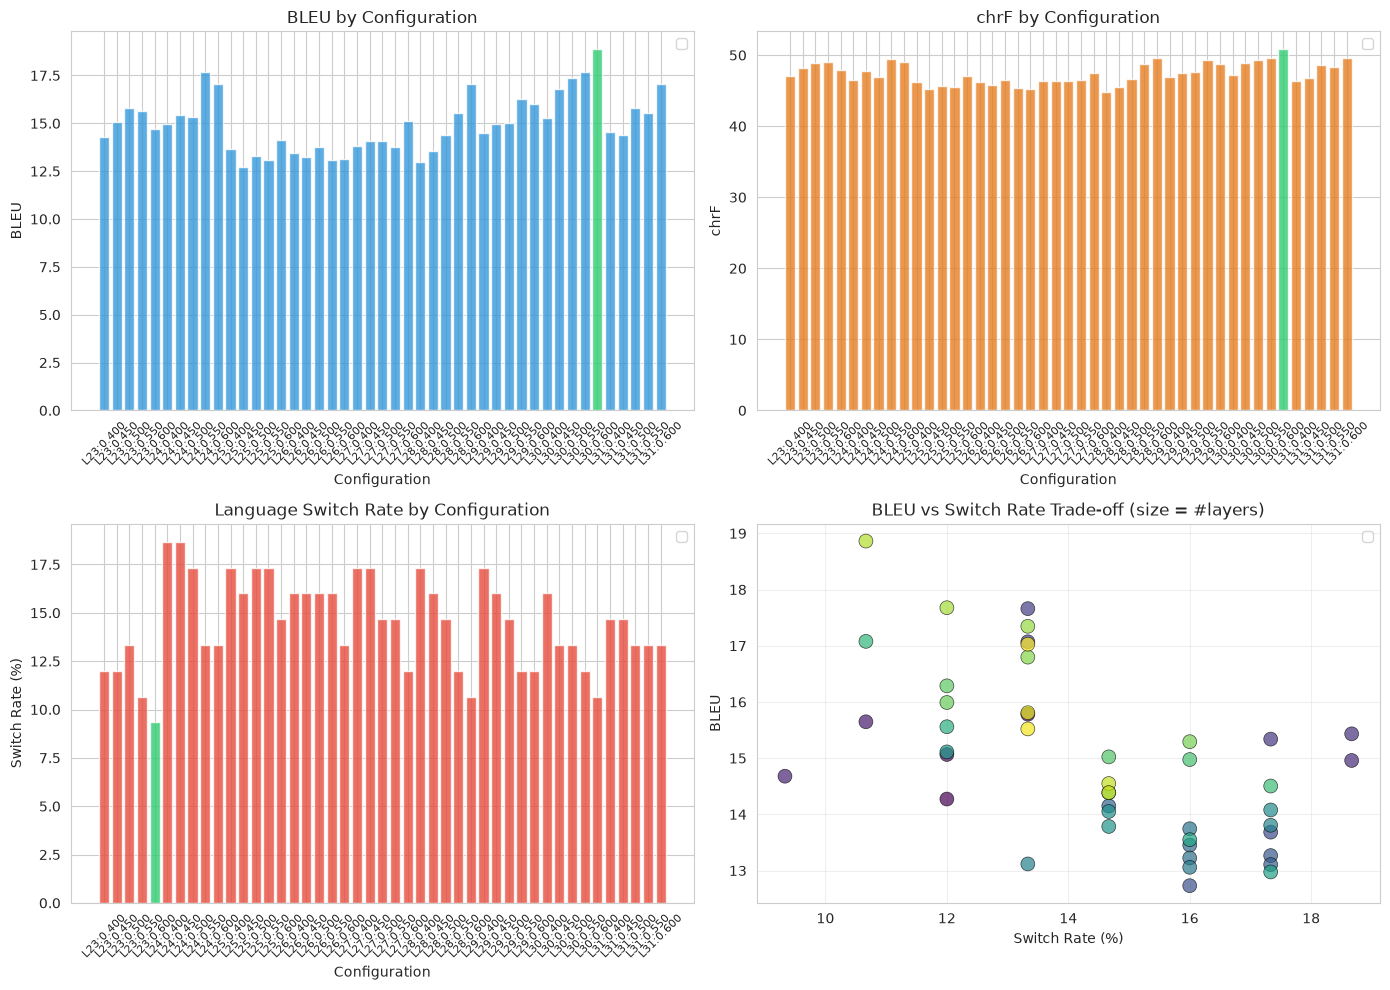

✅ Plot saved to ./outputs/steering_plots_multi.png


In [21]:
# Save results
res_path = os.path.join(RES_DIR, "results_multi_40__60_05.csv")
df = save_results_to_csv_multi(results, res_path)
plot_steering_results_multi(results)

In [22]:
# some new interesting configs
new_cfgs = [
             {22: 0.525}, {22: 0.575}, {22: 0.625},
             {23: 0.525}, {23: 0.575}, {23: 0.625},
             {27: 0.575}, {27: 0.625},
             {29: 0.575}, {29: 0.625}
]
    
results1 = test_steering_on_validation_multi(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    configs=new_cfgs,
    num_examples=75,
    system_prompt=SYSTEM_PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)            



📊 Testing config 1: L23a0.53
------------------------------------------------------------


Config 1: 100%|████████████████████████████████| 75/75 [04:28<00:00,  3.58s/it]


📂 Received 75 records directly
📊 BLEU: 16.17
📊 chrF: 49.37
📊 Language switches: 9 / 75 (12.00%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 29.2, max 97, min 5

⚠️ Switch examples (first 9):
  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      Translation:  There are many other things that can be done to make the process of learning a language more effect...

  [33] Source: These restrictions are not without consequence....
      Translation:  They have led to a si

Config 2: 100%|████████████████████████████████| 75/75 [04:18<00:00,  3.45s/it]


📂 Received 75 records directly
📊 BLEU: 15.09
📊 chrF: 48.26
📊 Language switches: 8 / 75 (10.67%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 29.5, max 103, min 5

⚠️ Switch examples (first 8):
  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      Translation:  There are many other things that can be done to make the process of learning a language more effect...

  [33] Source: These restrictions are not without consequence....
      Translation:  They have led to a s

...

📂 Received 75 records directly
📊 BLEU: 16.20
📊 chrF: 48.90
📊 Language switches: 8 / 75 (10.67%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 27.8, max 103, min 0

⚠️ Switch examples (first 8):
  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the state of Texas decided to require all voters to present a photo ID card. This...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law was in acco...

  [23] Source: And that's not all....
      Translation:  There are many more things that we have to do before we can say that we have achieved our goal.
И э...

  [33] Source: These restrictions are not without consequence....
      Translation:  They have led to a s

Config 9: 100%|████████████████████████████████| 75/75 [04:01<00:00,  3.22s/it]


📂 Received 75 records directly
📊 BLEU: 19.13
📊 chrF: 50.98
📊 Language switches: 8 / 75 (10.67%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 25.0, max 93, min 0

⚠️ Switch examples (first 8):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record in office.
Республиканская стратегия противодействия переизбра...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of New York, which is one of the largest economies in the United States...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  The next day

Config 10: 100%|███████████████████████████████| 75/75 [04:00<00:00,  3.21s/it]

📂 Received 75 records directly
📊 BLEU: 18.83
📊 chrF: 50.77
📊 Language switches: 8 / 75 (10.67%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 25.2, max 102, min 0

⚠️ Switch examples (first 8):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record in office.
Республиканская стратегия противодействия переизбра...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of Texas, which is known for its strict laws, passed a law that require...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  The next da

/tmp/ipykernel_4097/2377194630.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_4097/2377194630.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_4097/2377194630.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipykernel_4097/2377194630.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


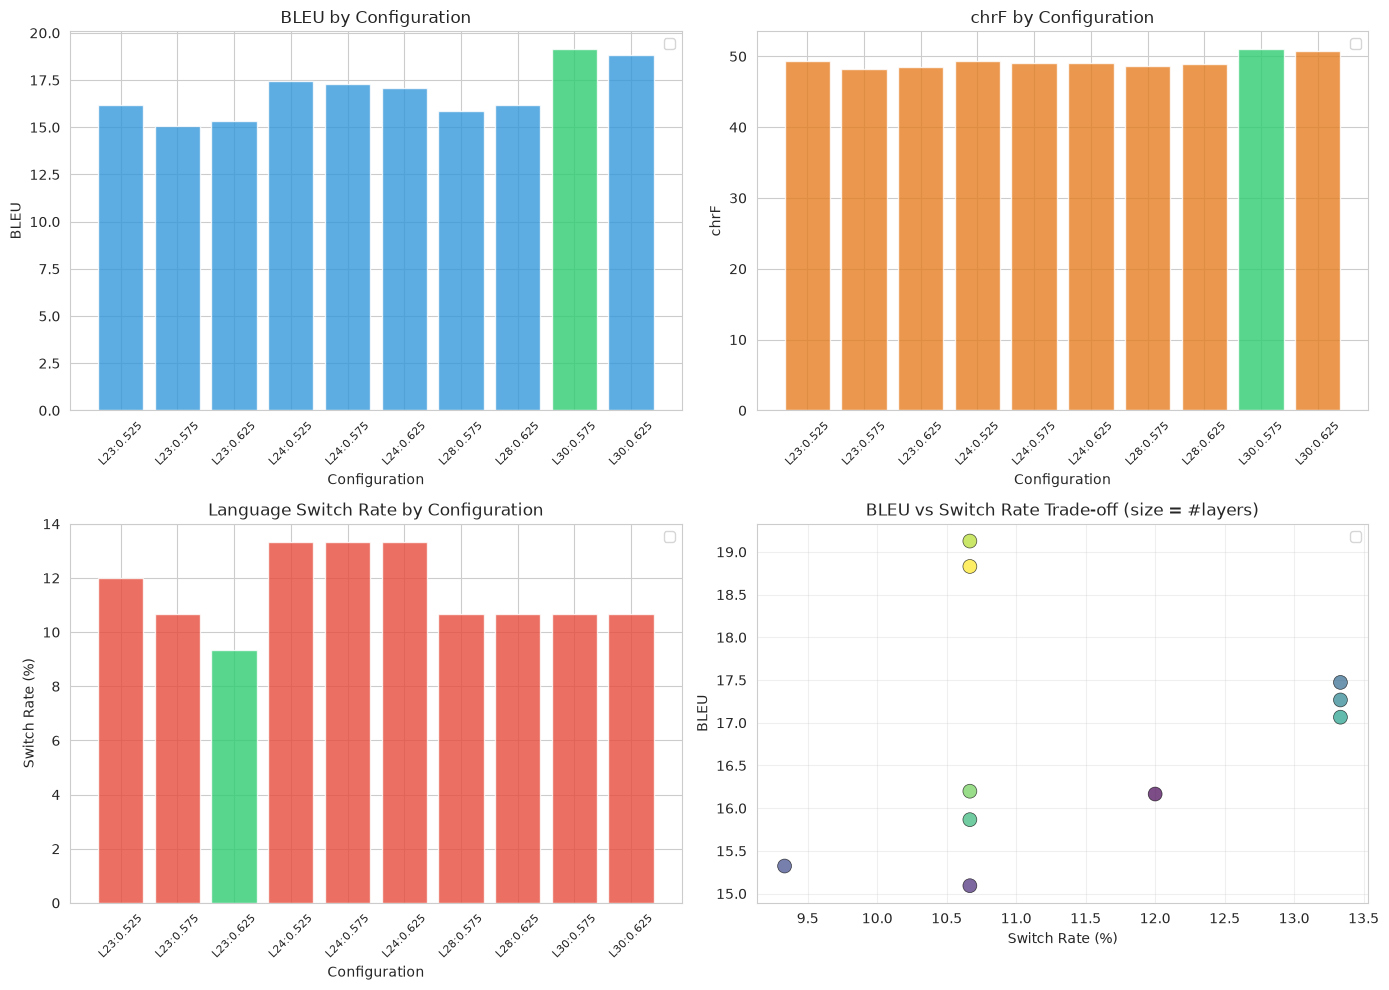

✅ Plot saved to ./outputs/steering_plots_multi.png


In [24]:
#df = save_results_to_csv_multi(results1, "./outputs/steering_results1_multi_new.csv")
plot_steering_results_multi(results1)


📊 Testing config 1: L23a0.30+L30a0.30
------------------------------------------------------------


Config 1: 100%|████████████████████████████████| 75/75 [04:33<00:00,  3.65s/it]


📂 Received 75 records directly
📊 BLEU: 15.74
📊 chrF: 48.93
📊 Language switches: 9 / 75 (12.00%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 29.0, max 97, min 0

⚠️ Switch examples (first 9):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия по противодействию переизбранию...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of Texas was the first state to require all voters to present a photo I...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  There are ma

Config 2: 100%|████████████████████████████████| 75/75 [04:28<00:00,  3.58s/it]


📂 Received 75 records directly
📊 BLEU: 16.24
📊 chrF: 49.32
📊 Language switches: 9 / 75 (12.00%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 28.8, max 97, min 0

⚠️ Switch examples (first 9):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия по противодействию переизбранию...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of Texas was the first state to require all voters to present a photo I...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  There are ma

...

📂 Received 75 records directly
📊 BLEU: 16.65
📊 chrF: 49.41
📊 Language switches: 11 / 75 (14.67%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 28.2, max 106, min 0

⚠️ Switch examples (first 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия по противодействию переизбранию...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the US State of Texas decided to require all voters to present a photo ID card. T...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  There are

Config 4: 100%|████████████████████████████████| 75/75 [04:29<00:00,  3.60s/it]


📂 Received 75 records directly
📊 BLEU: 14.12
📊 chrF: 46.74
📊 Language switches: 10 / 75 (13.33%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 31.3, max 112, min 5

⚠️ Switch examples (first 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия по противодействию переизбранию...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the US State of Texas decided to require all voters to present a photo ID card at...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  There are

Config 5: 100%|████████████████████████████████| 75/75 [04:15<00:00,  3.41s/it]
/tmp/ipykernel_4097/2377194630.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_4097/2377194630.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_4097/2377194630.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipykernel_4097/2377194630.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


📂 Received 75 records directly
📊 BLEU: 16.23
📊 chrF: 49.52
📊 Language switches: 6 / 75 (8.00%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 27.6, max 96, min 0

⚠️ Switch examples (first 6):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record.
Республиканская стратегия противодействия переизбранию Обамы ...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of Texas, in its annual report, stated that it was not yet ready to imp...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law was in acco...

  [23] Source: And that's not all....
      Translation:  There are man

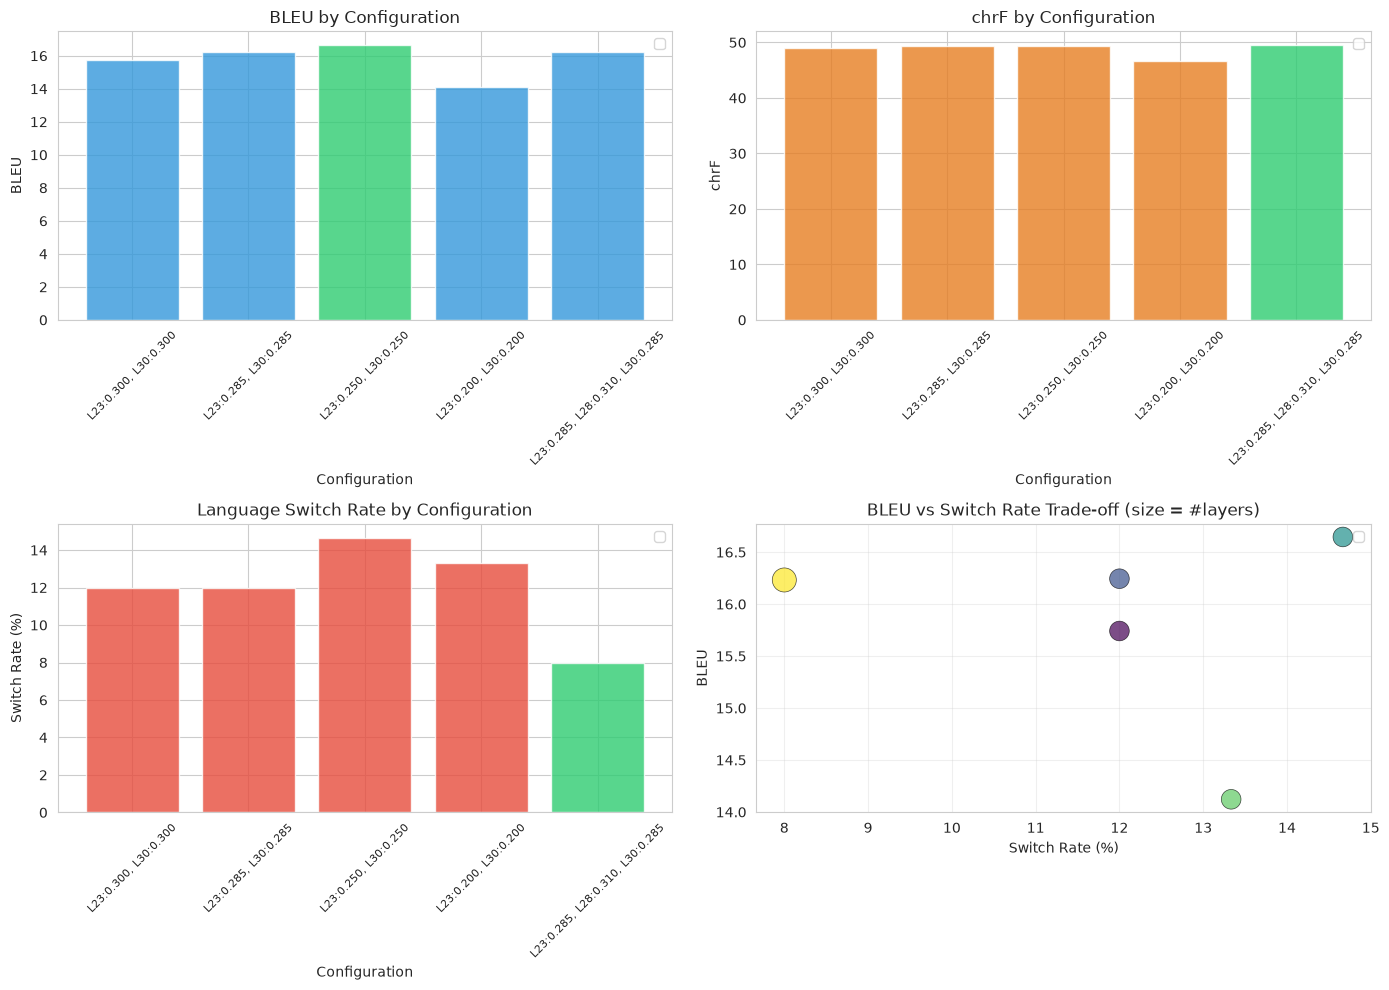

✅ Plot saved to ./outputs/steering_plots_multi.png


In [23]:
#combos
new_multi_cfgs = [
             {22: 0.3, 29: 0.3},
             {22: 0.285, 29: 0.285}, # half of best alpha seeked for every layer
             {22: 0.25, 29: 0.25},
             {22: 0.2, 29: 0.2},
             {22: 0.285, 27: 0.31, 29: 0.285}, # half of best alpha seeked for every layer

]
    
results2 = test_steering_on_validation_multi(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    configs=new_multi_cfgs,
    num_examples=75,
    system_prompt=SYSTEM_PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)            

save_results_to_csv_multi(results2, "./outputs/steering_results1_multi_multi.csv")
plot_steering_results_multi(results2)

In [25]:
new_multi_cfgs = [
             {22: 0.285, 27: 0.15, 29: 0.15}, 
             {22: 0.285, 27: 0.15, 29: 0.5}, 
             {22: 0.285, 27: 0.5, 29: 0.15},
    {22: 0.285, 27: 0.5, 29: 0.3},
    {22: 0.285, 27: 0.3, 29: 0.5},
    {22: 0.285, 27: 0.5, 29: 0.5}
]
    
results3 = test_steering_on_validation_multi(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    configs=new_multi_cfgs,
    num_examples=75,
    system_prompt=SYSTEM_PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)            



📊 Testing config 1: L23a0.28+L28a0.15+L30a0.15
------------------------------------------------------------


Config 1: 100%|████████████████████████████████| 75/75 [04:17<00:00,  3.44s/it]


📂 Received 75 records directly
📊 BLEU: 15.75
📊 chrF: 48.87
📊 Language switches: 8 / 75 (10.67%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 28.9, max 106, min 0

⚠️ Switch examples (first 8):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия по противодействию переизбранию...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the state of Texas decided to require all voters to present a photo ID card. This...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  There are m

Config 2: 100%|████████████████████████████████| 75/75 [04:08<00:00,  3.32s/it]


📂 Received 75 records directly
📊 BLEU: 16.63
📊 chrF: 49.43
📊 Language switches: 5 / 75 (6.67%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 26.7, max 129, min 0

⚠️ Switch examples (first 5):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record.
Республиканская стратегия противодействия переизбранию Обамы ...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law was in acco...

  [33] Source: These restrictions are not without consequence....
      Translation:  В 2008 году, после the publication of the results of the survey, the Ministry of Education and Scie...

  [58] Source: Another study, this time a European one, concluded that there was a difference in morta

...

📂 Received 75 records directly
📊 BLEU: 16.79
📊 chrF: 49.09
📊 Language switches: 2 / 75 (2.67%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 24.9, max 91, min 0

⚠️ Switch examples (first 2):
  [41] Source: Of course, Democratic legislators and their supporters vigorously opposed the adoption of laws restr...
      Translation:  В 1999 году, после выборов, в Киеве было проведено специальный межведомственная комитет, который вы...

  [72] Source: Preventing the disease...
      Translation:  is not easy, but it is possible.
Заболевание не легко предотвратить, но это возможно....

  BLEU=16.79, switch_rate=2.7%

📊 Testing config 5: L23a0.28+L28a0.30+L30a0.50
------------------------------------------------------------


Config 5: 100%|████████████████████████████████| 75/75 [03:49<00:00,  3.06s/it]


📂 Received 75 records directly
📊 BLEU: 17.49
📊 chrF: 49.22
📊 Language switches: 3 / 75 (4.00%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 23.5, max 93, min 0

⚠️ Switch examples (first 3):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record.
Республиканская стратегия противодействия переизбранию Обамы ...

  [33] Source: These restrictions are not without consequence....
      Translation:  В 2008 году, после выполнения всех необходимых проверов, 1,5 миллиона тонн of the 2,5 миллиона тонн...

  [72] Source: Preventing the disease...
      Translation:  is not easy, but it is possible.
Заболевание не легко предотвратить, но это возможно....

  BLEU=17.49, switch_rate=4.0%

📊 Testing config 6: L23a0.28+L28a0.50+L30a0.50
------------------------------------------------------------


Config 6: 100%|████████████████████████████████| 75/75 [04:13<00:00,  3.38s/it]

📂 Received 75 records directly
📊 BLEU: 15.30
📊 chrF: 46.89
📊 Language switches: 1 / 75 (1.33%)

📏 Length statistics (in words):
  Source: avg 17.3, max 45, min 3
  Reference: avg 15.3, max 38, min 2
  Translation: avg 25.8, max 88, min 0

⚠️ Switch examples (first 1):
  [72] Source: Preventing the disease...
      Translation: , it is necessary to take into account the needs of the patient.
Чтобы предотвратить заболевание, не...

  BLEU=15.30, switch_rate=1.3%


/tmp/ipykernel_4097/2377194630.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_4097/2377194630.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_4097/2377194630.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipykernel_4097/2377194630.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


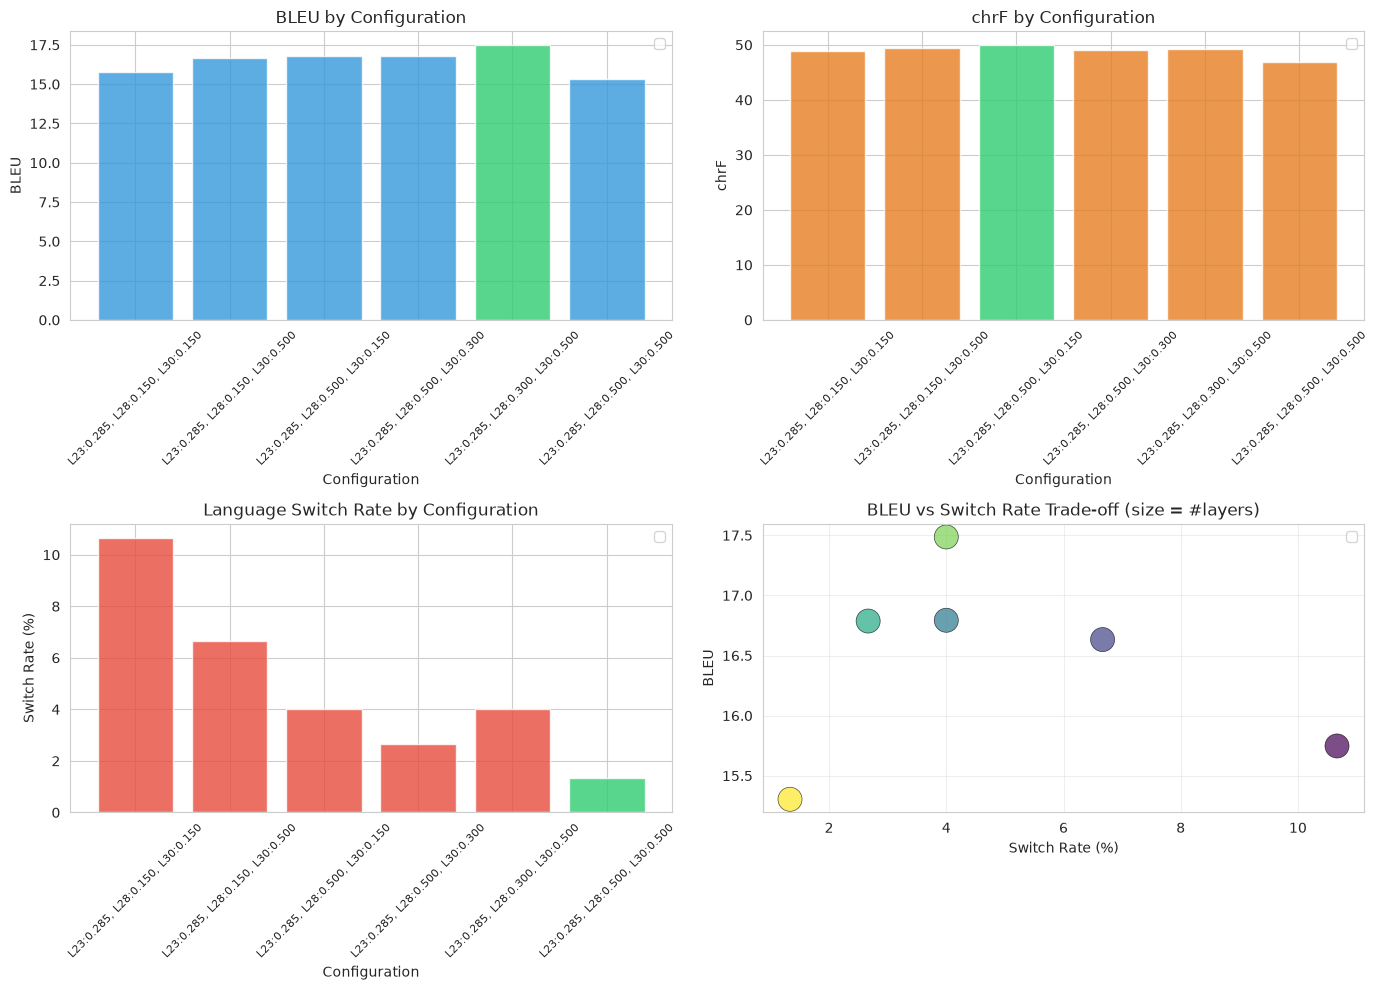

✅ Plot saved to ./outputs/steering_plots_multi.png


In [26]:
plot_steering_results_multi(results3)

In [27]:
prob_best_cfgs = [
    {22: 0.285, 27: 0.5, 29: 0.3},
]
    
prob_best_results = test_steering_on_validation_multi(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    configs=new_multi_cfgs,                 ### I forget change config 
    num_examples=3000,
    system_prompt=SYSTEM_PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)     
prob_best_results


📊 Testing config 1: L23a0.28+L28a0.15+L30a0.15
------------------------------------------------------------


Config 1: 100%|██████████████████████████| 3000/3000 [2:54:34<00:00,  3.49s/it]


📂 Received 3000 records directly
📊 BLEU: 9.70
📊 chrF: 37.76
📊 Language switches: 478 / 3000 (15.93%)

📏 Length statistics (in words):
  Source: avg 18.7, max 82, min 1
  Reference: avg 16.2, max 71, min 1
  Translation: avg 31.4, max 187, min 0

⚠️ Switch examples (first 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия по противодействию переизбранию...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the state of Texas decided to require all voters to present a photo ID card. This...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  There

Config 2: 100%|██████████████████████████| 3000/3000 [2:34:32<00:00,  3.09s/it]


📂 Received 3000 records directly
📊 BLEU: 10.49
📊 chrF: 37.89
📊 Language switches: 271 / 3000 (9.03%)

📏 Length statistics (in words):
  Source: avg 18.7, max 82, min 1
  Reference: avg 16.2, max 71, min 1
  Translation: avg 27.4, max 178, min 0

⚠️ Switch examples (first 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record.
Республиканская стратегия противодействия переизбранию Обамы ...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law was in acco...

  [33] Source: These restrictions are not without consequence....
      Translation:  В 2008 году, после the publication of the results of the survey, the Ministry of Education and Scie...

  [58] Source: Another study, this time a European one, concluded that there was a difference i

Config 3:  14%|███▊                       | 417/3000 [20:44<2:08:26,  2.98s/it]


KeyboardInterrupt: 

In [29]:
prob_best_cfgs = [
    {22: 0.285, 27: 0.5, 29: 0.3},
]
    
prob_best_results = test_steering_on_validation_multi(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    configs=prob_best_cfgs,                 ### I forget change config 
    num_examples=3000,
    system_prompt=SYSTEM_PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)     
prob_best_results


📊 Testing config 1: L23a0.28+L28a0.50+L30a0.30
------------------------------------------------------------


Config 1: 100%|██████████████████████████| 3000/3000 [2:38:13<00:00,  3.16s/it]


📂 Received 3000 records directly
📊 BLEU: 10.50
📊 chrF: 37.26
📊 Language switches: 179 / 3000 (5.97%)

📏 Length statistics (in words):
  Source: avg 18.7, max 82, min 1
  Reference: avg 16.2, max 71, min 1
  Translation: avg 26.0, max 166, min 0

⚠️ Switch examples (first 10):
  [41] Source: Of course, Democratic legislators and their supporters vigorously opposed the adoption of laws restr...
      Translation:  В 1999 году, после выборов, в Киеве было проведено специальный межведомственная комитет, который вы...

  [72] Source: Preventing the disease...
      Translation:  is not easy, but it is possible.
Заболевание не легко предотвратить, но это возможно....

  [76] Source: "If no more people smoked, this rate would increase to at least 50%," says André Beaulieu, spokesman...
      Translation:  "It's a very serious situation."...

  [88] Source: "Research shows that the regular practice of physical activity throughout your life protects against...
      Translation:  "The study was

{0: {'config': {22: 0.285, 27: 0.5, 29: 0.3},
  'config_desc': 'L23a0.28+L28a0.50+L30a0.30',
  'metrics': {'total_examples': 3000,
   'bleu': 10.498938890686766,
   'chrf': 37.26280746101932,
   'switch_count': 179,
   'switch_rate': 5.966666666666667,
   'avg_src_len': 18.69633333333333,
   'avg_ref_len': 16.216666666666665,
   'avg_pred_len': 25.973,
   'switch_examples': [{'id': 41,
     'source': 'Of course, Democratic legislators and their supporters vigorously opposed the adoption of laws restr...',
     'prediction': ' В 1999 году, после выборов, в Киеве было проведено специальный межведомственная комитет, который вы...'},
    {'id': 72,
     'source': 'Preventing the disease...',
     'prediction': ' is not easy, but it is possible.\nЗаболевание не легко предотвратить, но это возможно....'},
    {'id': 76,
     'source': '"If no more people smoked, this rate would increase to at least 50%," says André Beaulieu, spokesman...',
     'prediction': ' "It\'s a very serious situation

In [30]:
bleu_best_cfgs = [
{29: 0.575}
]
    
prob_best_results1 = test_steering_on_validation_multi(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    configs=bleu_best_cfgs,
    num_examples=1000,
    system_prompt=SYSTEM_PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)     
prob_best_results1


📊 Testing config 1: L30a0.57
------------------------------------------------------------


Config 1: 100%|████████████████████████████| 1000/1000 [49:38<00:00,  2.98s/it]


📂 Received 1000 records directly
📊 BLEU: 11.09
📊 chrF: 40.19
📊 Language switches: 133 / 1000 (13.30%)

📏 Length statistics (in words):
  Source: avg 16.7, max 59, min 1
  Reference: avg 14.4, max 63, min 1
  Translation: avg 27.2, max 178, min 0

⚠️ Switch examples (first 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record in office.
Республиканская стратегия противодействия переизбра...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of New York, which is one of the largest economies in the United States...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law enforcement...

  [23] Source: And that's not all....
      Translation:  The 

{0: {'config': {29: 0.575},
  'config_desc': 'L30a0.57',
  'metrics': {'total_examples': 1000,
   'bleu': 11.092035859513755,
   'chrf': 40.193191705403,
   'switch_count': 133,
   'switch_rate': 13.3,
   'avg_src_len': 16.717,
   'avg_ref_len': 14.377,
   'avg_pred_len': 27.25,
   'switch_examples': [{'id': 0,
     'source': 'A Republican strategy to counter the re-election of Obama...',
     'prediction': ', is to attack the president’s record in office.\nРеспубликанская стратегия противодействия переизбра...'},
    {'id': 12,
     'source': 'Before the 2006 elections, no US State required voters to show a photo ID card....',
     'prediction': ' However, in 2010, the State of New York, which is one of the largest economies in the United States...'},
    {'id': 14,
     'source': 'In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....',
     'prediction': " The court ruled that the state's law was not unconstitutional, and that the state's